# Experiment 1 — Spatial Upsampling Quality
**AnyUp3D Results · Section 4.2.3**  
Linear probe mIoU on ADE20K · DINOv2 backbone

## Cell 1 — Mount Drive + Install

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'scipy', 'transformers', '-q'], check=True)

Mounted at /content/drive


CompletedProcess(args=['pip', 'install', 'scipy', 'transformers', '-q'], returncode=0)

## Cell 2 — Clone Repo

In [2]:
import os

REPO_URL    = "https://github.com/mu-az88/anyup.git"
REPO_BRANCH = "3Dconv"
REPO_DIR    = "/content/anyup"

if not os.path.exists(REPO_DIR):
    os.system(f"git clone -b {REPO_BRANCH} {REPO_URL} {REPO_DIR}")
    print(f"Cloned → {REPO_DIR}  ✓")
else:
    print(f"Repo already exists at {REPO_DIR}  ✓")

os.system(f"pip install -e {REPO_DIR} -q")

Cloned → /content/anyup  ✓


0

## Cell 3 — Imports + Config

In [3]:
import sys
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
from scipy.stats import ttest_rel
from transformers import AutoModel

sys.path.insert(0, REPO_DIR)
from anyup.model import AnyUp
from anyup.model_2d import AnyUp2D

# ── Debug / Full run toggle ───────────────────────────────────────────────────
FULL_RUN = True   # ← flip to True when single-seed/epoch/condition passes cleanly

if FULL_RUN:
    SEEDS      = [42, 123, 456]
    NUM_EPOCHS = 3
    CONDITIONS = ["bilinear", "anyup2d", "anyup3d"]
else:
    SEEDS      = [42]
    NUM_EPOCHS = 1
    CONDITIONS = ["bilinear"]

print(f"FULL_RUN={FULL_RUN}  seeds={SEEDS}  epochs={NUM_EPOCHS}  conditions={CONDITIONS}")

# ── Paths ─────────────────────────────────────────────────────────────────────
CKPT_ANYUP3D   = "/content/drive/MyDrive/results/anyup3d_step500.pth"
OUTPUT_DIR     = Path("/content/drive/MyDrive/results/exp1")
FEAT_CACHE_DIR = Path("/content/drive/MyDrive/results/feat_cache_dinov2")
CKPT_HEAD_DIR  = OUTPUT_DIR / "head_ckpts"

for d in [OUTPUT_DIR, FEAT_CACHE_DIR, CKPT_HEAD_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Dataset / model constants ─────────────────────────────────────────────────
NUM_CLASSES  = 150
IGNORE_INDEX = 0        # ADE20K: 0 = unlabeled, excluded from mIoU

IMG_SIZE     = 224      # ↓ input spatial size; also update FEAT_SIZE if changed
FEAT_SIZE    = 16       # DINOv2-base patch size 14 → 224/14 = 16 tokens per side
FEAT_DIM     = 768      # DINOv2-base hidden dim

BATCH_SIZE   = 16       # ↓ reduce to 8 if OOM; affects train/eval/precompute loops
LR           = 1e-3
LR_DECAY_STEP= 2        # StepLR step; depends on NUM_EPOCHS

# AnyUp3D constructor — must match checkpoint exactly
ANYUP3D_CFG = dict(
    input_dim       = 3,
    qk_dim          = 128,
    kernel_size     = 1,
    kernel_size_lfu = 5,
    window_ratio    = 0.1,
    num_heads       = 4,
    t_k             = 3,
    window_t        = 3,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

FULL_RUN=True  seeds=[42, 123, 456]  epochs=3  conditions=['bilinear', 'anyup2d', 'anyup3d']
Device: cuda


## Cell 4 — Dataset (ADE20K)

In [4]:
ADE_DIR   = Path("/content/ADEChallengeData2016")
DRIVE_ADE = Path("/content/drive/MyDrive/results/ADEChallengeData2016.zip")

if not ADE_DIR.exists():
    if DRIVE_ADE.exists():
        print("Copying ADE20K from Drive...")
        os.system(f"cp {DRIVE_ADE} /content/ade20k.zip")
    else:
        print("Downloading ADE20K from MIT (~900 MB)...")
        os.system("wget -q http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip -O /content/ade20k.zip")
        os.system(f"cp /content/ade20k.zip {DRIVE_ADE}")
    os.system("unzip -q /content/ade20k.zip -d /content/")
print(f"ADE20K ready  ✓")

_img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

_denorm_mean = torch.tensor([0.485, 0.456, 0.406])
_denorm_std  = torch.tensor([0.229, 0.224, 0.225])

def denorm(t):
    return (t * _denorm_std[:, None, None] + _denorm_mean[:, None, None]).clamp(0, 1)

class ADE20KDataset(Dataset):
    """Raw image dataset — used only for precomputation."""
    def __init__(self, split):
        folder     = "training" if split == "train" else "validation"
        img_dir    = ADE_DIR / "images" / folder
        mask_dir   = ADE_DIR / "annotations" / folder

        print(f"DEBUG: Looking for images in: {img_dir}")
        print(f"DEBUG: Looking for masks in: {mask_dir}")

        self.imgs  = sorted(img_dir.glob("*.jpg"))
        self.masks = sorted(mask_dir.glob("*.png"))

        print(f"DEBUG: Found {len(self.imgs)} image files for split '{split}'")
        print(f"DEBUG: Found {len(self.masks)} mask files for split '{split}'")

        assert len(self.imgs) == len(self.masks) and len(self.imgs) > 0

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img  = _img_tf(Image.open(self.imgs[idx]).convert("RGB"))
        mask = Image.open(self.masks[idx])
        mask = transforms.functional.resize(
            mask, (IMG_SIZE, IMG_SIZE),
            interpolation=transforms.InterpolationMode.NEAREST,
        )
        mask = torch.from_numpy(np.array(mask)).long()
        return img, mask

class CachedFeatDataset(Dataset):
    def __init__(self, split_name, ade_dataset):
        feat_path = str(FEAT_CACHE_DIR / f"{split_name}_feats.npy")
        mask_path = str(FEAT_CACHE_DIR / f"{split_name}_masks.npy")
        N         = len(ade_dataset)
        # Keep as memmap — do NOT wrap in np.array() which forces full RAM load
        self.feats = np.memmap(feat_path, dtype='float16', mode='r',
                               shape=(N, FEAT_DIM, FEAT_SIZE, FEAT_SIZE))
        self.masks = np.memmap(mask_path, dtype='uint8', mode='r',
                               shape=(N, IMG_SIZE, IMG_SIZE))
        self.imgs  = ade_dataset.imgs
        print(f"  {split_name}: {N} samples (memmap)  ✓")

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img  = _img_tf(Image.open(self.imgs[idx]).convert("RGB"))
        feat = torch.from_numpy(self.feats[idx].astype('float32'))
        mask = torch.from_numpy(self.masks[idx].astype('int64'))
        return img, feat, mask

_train_ds = ADE20KDataset("train")
_val_ds   = ADE20KDataset("validation")
print(f"Raw — train: {len(_train_ds)}  val: {len(_val_ds)}")

Copying ADE20K from Drive...
ADE20K ready  ✓
DEBUG: Looking for images in: /content/ADEChallengeData2016/images/training
DEBUG: Looking for masks in: /content/ADEChallengeData2016/annotations/training
DEBUG: Found 20210 image files for split 'train'
DEBUG: Found 20210 mask files for split 'train'
DEBUG: Looking for images in: /content/ADEChallengeData2016/images/validation
DEBUG: Looking for masks in: /content/ADEChallengeData2016/annotations/validation
DEBUG: Found 2000 image files for split 'validation'
DEBUG: Found 2000 mask files for split 'validation'
Raw — train: 20210  val: 2000


## Cell 5 — DINOv2 Backbone + Precompute Features
Runs backbone once over full dataset and saves feats+masks to Drive.  
Skipped automatically on rerun if cache already exists.

In [5]:
print("Loading DINOv2...")
_dinov2 = AutoModel.from_pretrained("facebook/dinov2-base").to(DEVICE)
_dinov2.eval()
for p in _dinov2.parameters():
    p.requires_grad_(False)
print("DINOv2 loaded  ✓")

def extract_dinov2(imgs_4d):
    """
    imgs_4d : (B, 3, H, W)
    Returns : (B, FEAT_DIM, FEAT_SIZE, FEAT_SIZE)
    """
    with torch.no_grad():
        out    = _dinov2(pixel_values=imgs_4d)
        tokens = out.last_hidden_state[:, 1:, :]    # drop CLS token → (B, 256, 768)
        B, N, C = tokens.shape
        h = w = int(N ** 0.5)                       # 16×16 for IMG_SIZE=224
        return tokens.reshape(B, h, w, C).permute(0, 3, 1, 2).contiguous()

# ── Shape check ───────────────────────────────────────────────────────────────
with torch.no_grad():
    _dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    _feat  = extract_dinov2(_dummy)
assert _feat.shape == (1, FEAT_DIM, FEAT_SIZE, FEAT_SIZE), \
    f"Shape mismatch: {tuple(_feat.shape)}"
print(f"DINOv2 output shape: {tuple(_feat.shape)}  ✓")

def precompute_split(dataset, split_name):
    feat_path = str(FEAT_CACHE_DIR / f"{split_name}_feats.npy")
    mask_path = str(FEAT_CACHE_DIR / f"{split_name}_masks.npy")

    if os.path.exists(feat_path) and os.path.exists(mask_path):
        print(f"Cache exists for {split_name}, skipping.")
        return

    N = len(dataset)
    print(f"Precomputing {split_name} ({N} images)...")

    feat_mmap = np.memmap(feat_path, dtype='float16', mode='w+',
                          shape=(N, FEAT_DIM, FEAT_SIZE, FEAT_SIZE))
    mask_mmap = np.memmap(mask_path, dtype='uint8',   mode='w+',
                          shape=(N, IMG_SIZE, IMG_SIZE))

    loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)
    idx = 0
    for imgs, masks in loader:
        B     = imgs.size(0)
        feats = extract_dinov2(imgs.to(DEVICE))
        feat_mmap[idx:idx+B] = feats.cpu().numpy().astype('float16')
        mask_mmap[idx:idx+B] = masks.numpy().astype('uint8')
        idx += B
        del feats
        torch.cuda.empty_cache()
        if idx % 2000 == 0:
            print(f"  {idx}/{N}")

    feat_mmap.flush()
    mask_mmap.flush()
    print(f"Saved → {feat_path}")

precompute_split(_train_ds, "train")
precompute_split(_val_ds,   "val")

# Free GPU memory — backbone never needed again after precomputation
del _dinov2
torch.cuda.empty_cache()
print("Backbone removed from GPU  ✓")

# Instantiate cached datasets
_train_cached = CachedFeatDataset("train", _train_ds)
_val_cached   = CachedFeatDataset("val",   _val_ds)

Loading DINOv2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded  ✓
DINOv2 output shape: (1, 768, 16, 16)  ✓
Cache exists for train, skipping.
Cache exists for val, skipping.
Backbone removed from GPU  ✓
  train: 20210 samples (memmap)  ✓
  val: 2000 samples (memmap)  ✓


## Cell 6 — Load Models

In [6]:
# TStage must exist before torch.load so pickle can reconstruct it
class TStage:
    def __init__(self, t=None, start_step=None, batch_size=None):
        self.t          = t
        self.start_step = start_step
        self.batch_size = batch_size

# ── AnyUp3D ───────────────────────────────────────────────────────────────────
_anyup3d = AnyUp(**ANYUP3D_CFG).to(DEVICE).eval()

ckpt = torch.load(CKPT_ANYUP3D, map_location="cpu", weights_only=False)
sd   = ckpt["anyup"] if "anyup" in ckpt else ckpt.get(
    "model_state_dict", ckpt.get("model", ckpt.get("state_dict", ckpt)))
for k in ("step", "global_step", "t_stage"):
    if k in ckpt:
        print(f"  checkpoint {k}: {ckpt[k]}")
sd = {k.replace("module.", "", 1) if k.startswith("module.") else k: v
      for k, v in sd.items()}
missing, unexpected = _anyup3d.load_state_dict(sd, strict=False)
print(f"AnyUp3D — {len(missing)} missing  {len(unexpected)} unexpected")
if not missing and not unexpected:
    print("Strict match  ✓")
for p in _anyup3d.parameters():
    p.requires_grad_(False)

# ── 2D AnyUp ──────────────────────────────────────────────────────────────────
_anyup2d = AnyUp2D().to(DEVICE).eval()
_sd2d    = torch.hub.load_state_dict_from_url(
    "https://github.com/wimmerth/anyup/releases/download/checkpoint/anyup_paper.pth",
    map_location=DEVICE, progress=True,
)
_anyup2d.load_state_dict(_sd2d)
for p in _anyup2d.parameters():
    p.requires_grad_(False)
print("2D AnyUp loaded  ✓")

# ── Upsample functions ────────────────────────────────────────────────────────
@torch.no_grad()
def upsample_bilinear(imgs, feats_5d):
    return F.interpolate(feats_5d.squeeze(2), size=(IMG_SIZE, IMG_SIZE),
                         mode='bilinear', align_corners=False)

@torch.no_grad()
def upsample_anyup2d(imgs, feats_5d):
    feat_4d = feats_5d.squeeze(2)
    return _anyup2d(imgs, feat_4d, output_size=(IMG_SIZE, IMG_SIZE))

@torch.no_grad()
def upsample_anyup3d(imgs, feats_5d):
    out_5d = _anyup3d(imgs.unsqueeze(2), feats_5d,
                      output_size=(IMG_SIZE, IMG_SIZE))
    return out_5d.squeeze(2)

UPSAMPLERS = {
    "bilinear" : upsample_bilinear,
    "anyup2d"  : upsample_anyup2d,
    "anyup3d"  : upsample_anyup3d,
}

  checkpoint global_step: 500
AnyUp3D — 0 missing  0 unexpected
Strict match  ✓
Downloading: "https://github.com/wimmerth/anyup/releases/download/checkpoint/anyup_paper.pth" to /root/.cache/torch/hub/checkpoints/anyup_paper.pth


100%|██████████| 3.38M/3.38M [00:00<00:00, 43.0MB/s]

2D AnyUp loaded  ✓


## Cell 7 — Head + mIoU Utilities

In [7]:
def make_head():
    return nn.Conv2d(FEAT_DIM, NUM_CLASSES, kernel_size=1).to(DEVICE)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def compute_miou(conf_mat):
    tp    = conf_mat.diag().float()
    fp    = (conf_mat.sum(0) - conf_mat.diag()).float()
    fn    = (conf_mat.sum(1) - conf_mat.diag()).float()
    iou   = tp / (tp + fp + fn + 1e-10)
    valid = conf_mat.sum(1) > 0
    return iou[valid].mean().item() * 100.0

def update_conf_mat(conf_mat, logits, targets):
    preds    = logits.argmax(dim=1)
    mask     = (targets != IGNORE_INDEX)
    tgt_flat = (targets[mask] - 1).cpu()    # shift 1–150 → 0–149
    prd_flat = preds[mask].cpu()
    valid    = (tgt_flat >= 0) & (tgt_flat < NUM_CLASSES) & \
               (prd_flat >= 0) & (prd_flat < NUM_CLASSES)
    idx      = tgt_flat[valid] * NUM_CLASSES + prd_flat[valid]
    conf_mat += torch.bincount(idx, minlength=NUM_CLASSES * NUM_CLASSES) \
                     .reshape(NUM_CLASSES, NUM_CLASSES)

## Cell 8 — Train + Evaluate

In [8]:
def head_ckpt_path(condition, seed):
    return CKPT_HEAD_DIR / f"{condition}_seed{seed}.pt"

def save_head_ckpt(condition, seed, head, optimizer, scheduler, epoch, miou):
    torch.save({
        "epoch"    : epoch,
        "miou"     : miou,
        "head"     : head.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
    }, head_ckpt_path(condition, seed))

def load_head_ckpt(condition, seed, head, optimizer, scheduler):
    path = head_ckpt_path(condition, seed)
    if not path.exists():
        return 0
    ckpt = torch.load(path, map_location=DEVICE)
    head.load_state_dict(ckpt["head"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    print(f"    Resumed from epoch {ckpt['epoch']}  mIoU={ckpt['miou']:.2f}")
    return ckpt["epoch"]

def train_one_epoch(head, optimizer, upsample_fn, loader):
    head.train()
    total_loss, n = 0.0, 0
    for imgs, feats, masks in loader:
        imgs  = imgs.to(DEVICE)
        feats = feats.unsqueeze(2).to(DEVICE)
        masks = (masks.to(DEVICE) - 1)          # shift: 1–150 → 0–149; 0 → -1 (ignore)
        logits = head(upsample_fn(imgs, feats))
        loss   = F.cross_entropy(logits, masks, ignore_index=-1)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n += 1
    return total_loss / max(n, 1)

@torch.no_grad()
def evaluate_miou(head, upsample_fn, loader):
    head.eval()
    conf_mat = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)
    for imgs, feats, masks in loader:
        imgs  = imgs.to(DEVICE)
        feats = feats.unsqueeze(2).to(DEVICE)
        masks = masks.to(DEVICE)
        logits = head(upsample_fn(imgs, feats))
        update_conf_mat(conf_mat, logits, masks)
    return compute_miou(conf_mat)

def run_seed(seed, condition_name):
    print(f"  seed={seed}  condition={condition_name}")
    set_seed(seed)

    upsample_fn = UPSAMPLERS[condition_name]
    head        = make_head()
    optimizer   = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=1e-4)
    scheduler   = torch.optim.lr_scheduler.StepLR(optimizer,
                      step_size=LR_DECAY_STEP, gamma=0.1)

    start_epoch = load_head_ckpt(condition_name, seed, head, optimizer, scheduler)

    # Return checkpointed mIoU immediately if all epochs already complete
    if start_epoch >= NUM_EPOCHS:
        final_miou = torch.load(head_ckpt_path(condition_name, seed), map_location=DEVICE)["miou"]
        print(f"    Already complete — mIoU={final_miou:.2f}")
        return final_miou, head
    g = torch.Generator()
    g.manual_seed(seed)
    train_loader = DataLoader(_train_cached, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2,
                              pin_memory=True, generator=g)
    val_loader   = DataLoader(_val_cached,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2,
                              pin_memory=True)

    final_miou = None
    for epoch in range(start_epoch + 1, NUM_EPOCHS + 1):
        loss = train_one_epoch(head, optimizer, upsample_fn, train_loader)
        scheduler.step()
        miou = evaluate_miou(head, upsample_fn, val_loader)
        print(f"    epoch {epoch:02d}/{NUM_EPOCHS}  loss={loss:.4f}  mIoU={miou:.2f}")
        save_head_ckpt(condition_name, seed, head, optimizer, scheduler, epoch, miou)
        final_miou = miou

    return final_miou, head

## Cell 9 — Main Experiment

In [9]:
results    = {c: [] for c in CONDITIONS}
heads_last = {}

for condition in CONDITIONS:
    print(f"\n{'─'*60}")
    print(f"Condition: {condition.upper()}")
    print(f"{'─'*60}")
    for seed in SEEDS:
        miou, head = run_seed(seed, condition)
        results[condition].append(miou)
        print(f"  → final mIoU: {miou:.2f}")
    heads_last[condition] = head

with open(OUTPUT_DIR / "exp1_results.json", 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nResults saved → {OUTPUT_DIR}/exp1_results.json")


────────────────────────────────────────────────────────────
Condition: BILINEAR
────────────────────────────────────────────────────────────
  seed=42  condition=bilinear
    Resumed from epoch 3  mIoU=39.57
    Already complete — mIoU=39.57
  → final mIoU: 39.57
  seed=123  condition=bilinear
    Resumed from epoch 3  mIoU=39.57
    Already complete — mIoU=39.57
  → final mIoU: 39.57
  seed=456  condition=bilinear
    Resumed from epoch 3  mIoU=39.48
    Already complete — mIoU=39.48
  → final mIoU: 39.48

────────────────────────────────────────────────────────────
Condition: ANYUP2D
────────────────────────────────────────────────────────────
  seed=42  condition=anyup2d
    Resumed from epoch 3  mIoU=42.36
    Already complete — mIoU=42.36
  → final mIoU: 42.36
  seed=123  condition=anyup2d
    Resumed from epoch 3  mIoU=42.38
    Already complete — mIoU=42.38
  → final mIoU: 42.38
  seed=456  condition=anyup2d
    Resumed from epoch 3  mIoU=42.34
    Already complete — mIoU=42.3

## Cell 10 — Results Table + t-test
Only meaningful when `FULL_RUN=True` (3 seeds needed for t-test)

In [10]:
print("\n" + "═"*62)
print(f"{'EXPERIMENT 1 — SPATIAL UPSAMPLING QUALITY':^62}")
print(f"{'ADE20K Linear Probe · mIoU (%) · DINOv2 backbone':^62}")
print("═"*62)
print(f"{'Condition':<22} {'Seed(s)':>20}  {'Mean':>8}  {'Std':>6}")
print("─"*62)

means, stds = {}, {}
LABELS = {"bilinear": "Bilinear",
           "anyup2d" : "2D AnyUp (per-frame)",
           "anyup3d" : "AnyUp3D (ours)"}

for condition in CONDITIONS:
    scores = results[condition]
    mu     = float(np.mean(scores))
    std    = float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0
    means[condition] = mu
    stds[condition]  = std
    score_str = "  ".join(f"{s:.2f}" for s in scores)
    print(f"{LABELS[condition]:<22} {score_str:>20}  {mu:>8.2f}  {std:>6.2f}")

print("═"*62)

if FULL_RUN and "anyup3d" in results and "bilinear" in results:
    t1, p1 = ttest_rel(results["anyup3d"], results["bilinear"])
    t2, p2 = ttest_rel(results["anyup3d"], results["anyup2d"])
    print(f"\nPaired t-test  AnyUp3D vs Bilinear:  t={t1:.4f}  p={p1:.4f}  {'✓ p<0.05' if p1<0.05 else 'NOT significant'}")
    print(f"Paired t-test  AnyUp3D vs 2D AnyUp:  t={t2:.4f}  p={p2:.4f}  {'✓ p<0.05' if p2<0.05 else 'NOT significant'}")
else:
    print("\n(t-test skipped — set FULL_RUN=True and run 3 seeds for significance testing)")


══════════════════════════════════════════════════════════════
          EXPERIMENT 1 — SPATIAL UPSAMPLING QUALITY           
       ADE20K Linear Probe · mIoU (%) · DINOv2 backbone       
══════════════════════════════════════════════════════════════
Condition                           Seed(s)      Mean     Std
──────────────────────────────────────────────────────────────
Bilinear                39.57  39.57  39.48     39.54    0.05
2D AnyUp (per-frame)    42.36  42.38  42.34     42.36    0.02
AnyUp3D (ours)          41.92  41.95  41.92     41.93    0.01
══════════════════════════════════════════════════════════════

Paired t-test  AnyUp3D vs Bilinear:  t=83.2165  p=0.0001  ✓ p<0.05
Paired t-test  AnyUp3D vs 2D AnyUp:  t=-65.7884  p=0.0002  ✓ p<0.05


## Cell 11 — Qualitative Figure
4 examples: Original | GT | one column per condition

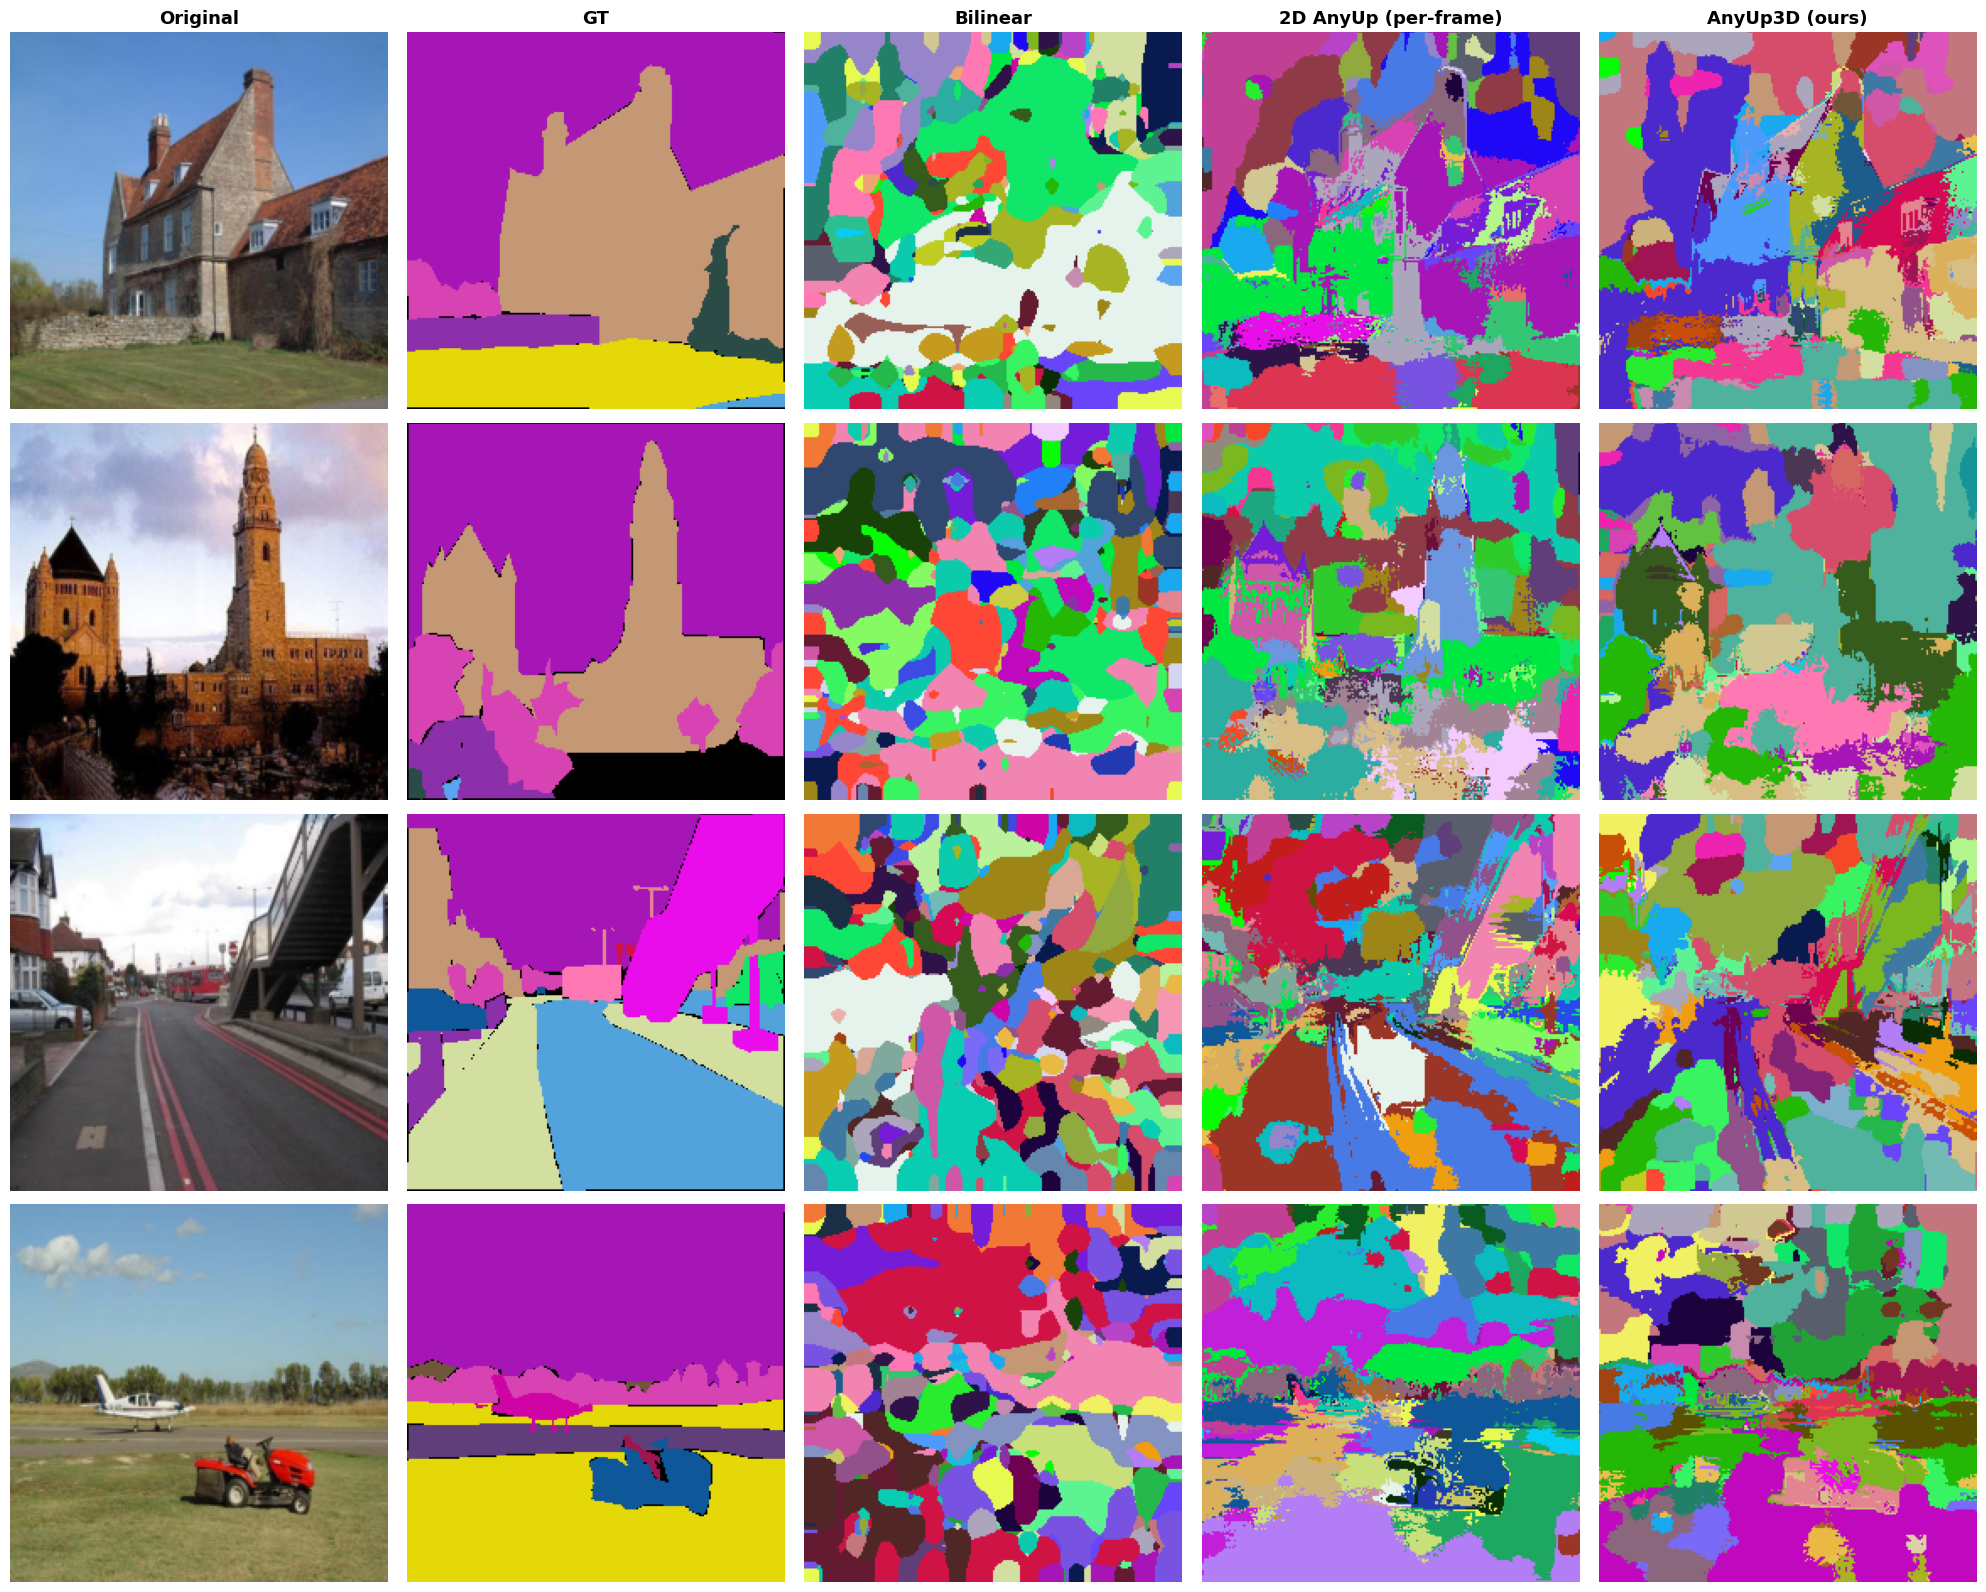

Figure saved → /content/drive/MyDrive/results/exp1/exp1_qualitative.png


In [11]:
import matplotlib.pyplot as plt

np.random.seed(0)
_palette       = np.random.randint(0, 255, size=(NUM_CLASSES + 1, 3), dtype=np.uint8)
_palette[0]    = [0, 0, 0]

def mask_to_rgb(mask_np):
    return _palette[np.clip(mask_np, 0, NUM_CLASSES)]

N_EXAMPLES = 4     # ↓ reduce to 2 if short on time

_sample_imgs, _sample_masks = [], []
for imgs, _, masks in DataLoader(_val_cached, batch_size=N_EXAMPLES, shuffle=False):
    _sample_imgs  = imgs
    _sample_masks = masks
    break

_imgs_dev  = _sample_imgs.to(DEVICE)
_feats_dev = torch.stack([_val_cached[i][1] for i in range(N_EXAMPLES)]) \
                  .unsqueeze(2).to(DEVICE)

_preds = {}
for cond in CONDITIONS:
    with torch.no_grad():
        logits        = make_head().to(DEVICE)(UPSAMPLERS[cond](_imgs_dev, _feats_dev))
    _preds[cond]  = logits.argmax(dim=1).cpu().numpy() + 1  # shift to palette space

_ncols  = 2 + len(CONDITIONS)
_fig, _axes = plt.subplots(N_EXAMPLES, _ncols,
                            figsize=(4 * _ncols, 4 * N_EXAMPLES), squeeze=False)

_col_titles = ["Original", "GT"] + [LABELS[c] for c in CONDITIONS]
for col, title in enumerate(_col_titles):
    _axes[0][col].set_title(title, fontsize=13, fontweight='bold')

for row in range(N_EXAMPLES):
    _axes[row][0].imshow(denorm(_sample_imgs[row]).permute(1, 2, 0).numpy())
    _axes[row][1].imshow(mask_to_rgb(_sample_masks[row].numpy()))
    for col_idx, cond in enumerate(CONDITIONS, start=2):
        _axes[row][col_idx].imshow(mask_to_rgb(_preds[cond][row]))
    for ax in _axes[row]:
        ax.axis('off')

_fig.tight_layout(pad=1.0)
_fig_path = OUTPUT_DIR / "exp1_qualitative.png"
_fig.savefig(str(_fig_path), dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved → {_fig_path}")